# With this script we check the DINEOF run and decides what data has been poorly reconstructed and will be removed in the post processing

The run has been done with the script run_dineof_2.sh in the /dineof-3.0 folder
Input : RHED and SEAL daily data from July 2019 to December 2021

- Number of EOF modes retained : 25
- Convergence level required : 0.1e-2



In [1]:
%reset 

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


-----

## EOF outputs

Generally the EOF modes look ok.

However I am a bit worried about the EOF 2 (see annotation), because I think that it is where the spin comes from in the vector reconstruction. 

EOF 3 shows very ugly peaks when both radials are missing, and higher variability when one radial is missing. --> Maybe need to remove some data

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
import xarray as xr
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
from datetime import timedelta

get_ipython().run_line_magic('run', '"/media/nbourg/One Touch/PhD/Separation_HFR_EAC/toolbox.ipynb"')
warnings.filterwarnings('ignore')


path = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data_Processing/Gap_Filling/run_newcastle/'
rhed_pre = xr.open_dataset(path+'pre_post_processing/daily_2019_2021_RHED_pre.nc')
seal_pre = xr.open_dataset(path+'pre_post_processing/daily_2019_2021_SEAL_pre.nc')

sc_rhed_pre = get_spatial_coverage(rhed_pre['v'].values)
sc_seal_pre = get_spatial_coverage(seal_pre['v'].values)

rhed_filled = xr.open_dataset(path+'my_result_folder/log2/daily_2019_2021_RHED_din.nc')
seal_filled = xr.open_dataset(path+'my_result_folder/log2/daily_2019_2021_SEAL_din.nc')

rhed_mask = xr.open_dataset(path+'pre_post_processing/mask_2019_2021_RHED.nc')
seal_mask = xr.open_dataset(path+'pre_post_processing/mask_2019_2021_SEAL.nc')

yes_rhed = np.transpose(rhed_mask['mask'].values)
yes_rhed = yes_rhed[yes_rhed==1]

timeseries_eof = np.loadtxt(path+'my_result_folder/log2/outputEof.rghvec')
eof = np.loadtxt(path+'my_result_folder/log2/outputEof.lftvec')
eof_rhed_file = eof[:yes_rhed.shape[0],:]
eof_seal_file = eof[yes_rhed.shape[0]:,:]


eof_rhed = np.nan*np.zeros((rhed_mask['mask'].shape[1],rhed_mask['mask'].shape[0],eof.shape[1]))
eof_seal = np.nan*np.zeros((seal_mask['mask'].shape[1],seal_mask['mask'].shape[0],eof.shape[1]))

eof_rhed[np.transpose(rhed_mask['mask'].values)==1]=eof_rhed_file
eof_seal[np.transpose(seal_mask['mask'].values)==1]=eof_seal_file

pd_time=np.array([pd.datetime(2019,7,1)+timedelta(days=i) for i in range(1,timeseries_eof.shape[0]+1)])

Text(150, -32, 'Weird rotation?')

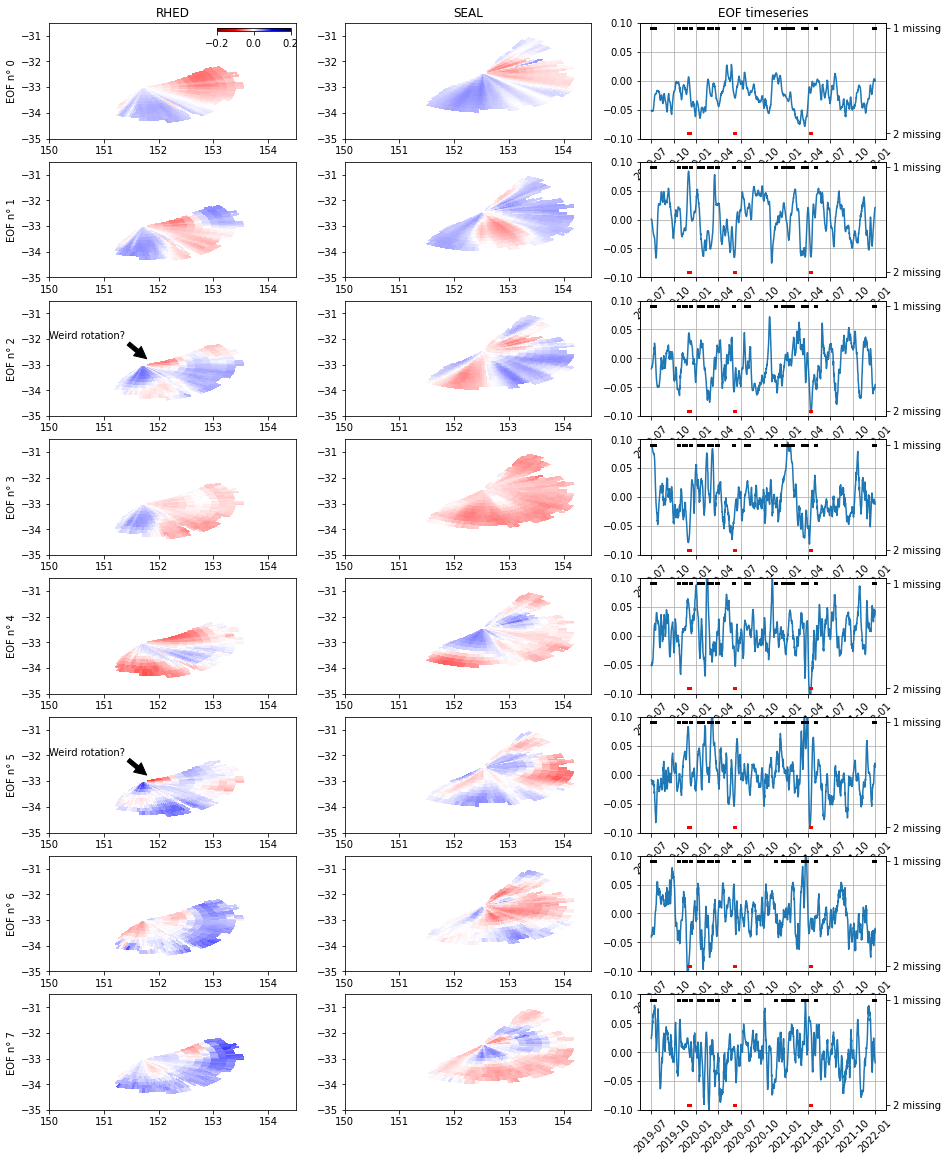

In [3]:
fig, axs = plt.subplots(ncols=3,nrows=8,figsize=(15,20))
for i in range(0,8):
    
    axs[i,0].pcolor(rhed_pre['lon'],rhed_pre['lat'],np.transpose(eof_rhed[:,:,i]),vmin=-0.2,vmax=.2,cmap='seismic_r')
    pc=axs[i,1].pcolor(seal_pre['lon'],seal_pre['lat'],np.transpose(eof_seal[:,:,i]),vmin=-0.2,vmax=.2,cmap='seismic_r')
    axs[i,2].set_ylim(-0.1,0.1)
    axs[i,0].set_ylim(-35,-30.5)
    axs[i,1].set_ylim(-35,-30.5)

    axs[i,0].set_xlim(150,154.5)
    axs[i,1].set_xlim(150,154.5)

    sp = axs[i,2].twinx()
    
    missing = np.nan*np.zeros(sc_rhed_pre.shape)
    missing[np.logical_and(sc_rhed_pre==0,sc_seal_pre==0)]=0
    
    missing_one = np.nan*np.zeros(sc_rhed_pre.shape)
    missing_one[np.logical_or(sc_rhed_pre==0,sc_seal_pre==0)]=1
    missing_one[missing==0]=np.nan
    
    sp.plot(pd_time,missing,c='r',linewidth=3,zorder=2)
    sp.plot(pd_time,missing_one,c='k',linewidth=3,zorder=2)
    sp.set_yticks([0,1])
    sp.set_yticklabels(['2 missing','1 missing'])
    axs[i,2].tick_params(axis='x', rotation=45)
    sp.tick_params(axis='x', rotation=45)

    axs[i,2].grid(zorder=0)
    axs[i,2].plot(pd_time,timeseries_eof[:,i],zorder=3)

    axs[i,0].set_ylabel('EOF n° '+str(i))

cbaxes = inset_axes(axs[0,0], width="30%", height="3%", loc=1)

fig.colorbar(pc,cax=cbaxes,orientation='horizontal')
axs[0,2].title.set_text('EOF timeseries')
axs[0,0].title.set_text('RHED')
axs[0,1].title.set_text('SEAL')


#ANNOTATIONS

axs[2,0].annotate('Weird rotation?', xy=(151.8, -32.8), xytext=(150, -32),
            arrowprops=dict(facecolor='black', shrink=0.05))


axs[5,0].annotate('Weird rotation?', xy=(151.8, -32.8), xytext=(150, -32),
            arrowprops=dict(facecolor='black', shrink=0.05))




The weird rotation thing very close to the coast is 'reproduced' by DINEOF but it is originally present in the real data from RHED. And is also in the Quality Controlled vectorial data from thredds (see figure).

However, when there is long holes, this pattern is way too intense. --> Need to determine the length of a temporal hole over which we need to remove the data.


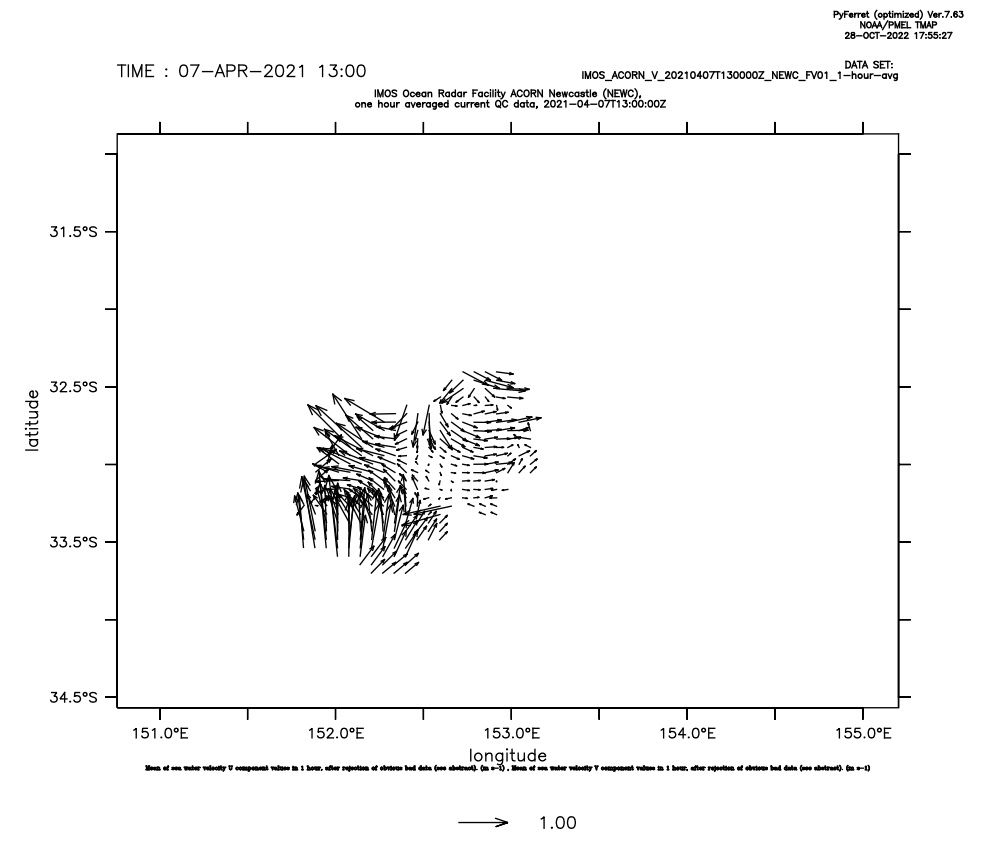

----

# Some example of smoothing 
Seems like the algorithm is doing a lot of smoothing that was really needed.

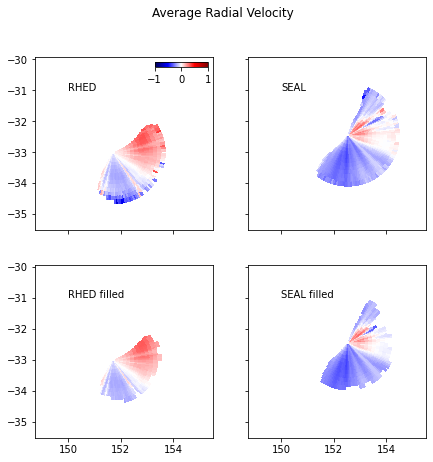

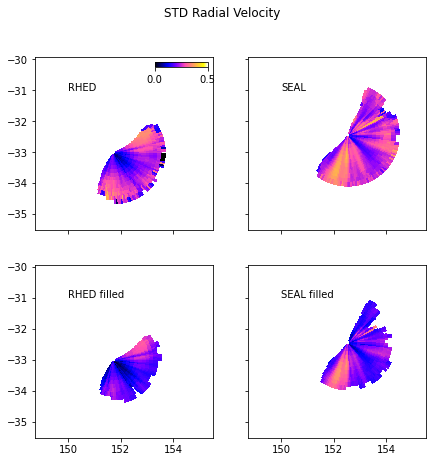

In [4]:
fig,axs=plt.subplots(ncols=2,nrows=2,sharex=True,sharey=True,figsize=(7,7))
pc=axs[0,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,np.nanmean(rhed_pre['v'].values,axis=0),vmin=-1,vmax=1,cmap='seismic')
axs[1,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,np.nanmean(rhed_filled['v'].values,axis=0),vmin=-1,vmax=1,cmap='seismic')

axs[0,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,np.nanmean(seal_pre['v'].values,axis=0),vmin=-1,vmax=1,cmap='seismic')
axs[1,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,np.nanmean(seal_filled['v'].values,axis=0),vmin=-1,vmax=1,cmap='seismic')

axs[0,0].text(150,-31,'RHED')
axs[1,0].text(150,-31,'RHED filled')

axs[0,1].text(150,-31,'SEAL')
axs[1,1].text(150,-31,'SEAL filled')
fig.suptitle('Average Radial Velocity ')

cbaxes = inset_axes(axs[0,0], width="30%", height="3%", loc=1)

fig.colorbar(pc,cax=cbaxes,orientation='horizontal')




fig,axs=plt.subplots(ncols=2,nrows=2,sharex=True,sharey=True,figsize=(7,7))
pc=axs[0,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,np.nanstd(rhed_pre['v'].values,axis=0),vmin=0,vmax=.5,cmap='gnuplot2')
axs[1,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,np.nanstd(rhed_filled['v'].values,axis=0),vmin=0,vmax=.5,cmap='gnuplot2')

axs[0,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,np.nanstd(seal_pre['v'].values,axis=0),vmin=0,vmax=.5,cmap='gnuplot2')
axs[1,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,np.nanstd(seal_filled['v'].values,axis=0),vmin=0,vmax=.5,cmap='gnuplot2')

axs[0,0].text(150,-31,'RHED')
axs[1,0].text(150,-31,'RHED filled')

axs[0,1].text(150,-31,'SEAL')
axs[1,1].text(150,-31,'SEAL filled')
fig.suptitle('STD Radial Velocity ')

cbaxes = inset_axes(axs[0,0], width="30%", height="3%", loc=1)

fig.colorbar(pc,cax=cbaxes,orientation='horizontal')


Text(130, 480, 'Some long paliers')

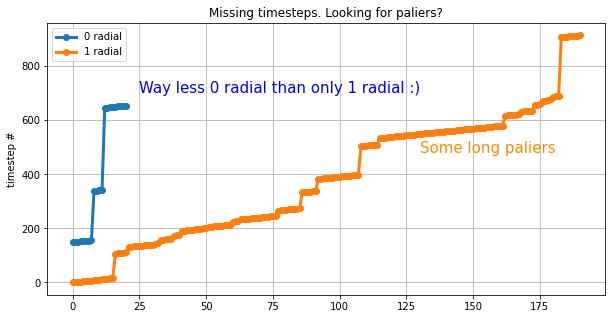

In [5]:
indices_one = np.where(missing_one==1)
indices_two = np.where(missing==0)

plt.figure(figsize=(10,5))
plt.grid()
plt.plot(indices_two[0],label='0 radial',linewidth=3,marker='o')
plt.ylabel("timestep #")
plt.plot(indices_one[0],label='1 radial',linewidth=3,marker='o')
plt.legend()
plt.title("Missing timesteps. Looking for paliers?")
plt.text(25,700,"Way less 0 radial than only 1 radial :)",fontsize=15,color='b')
plt.text(130,480,"Some long paliers",c='darkorange',fontsize=15)

### Example of good smoothing of RHED when SEAL is missing

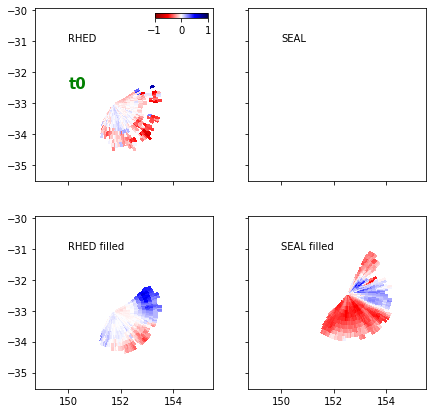

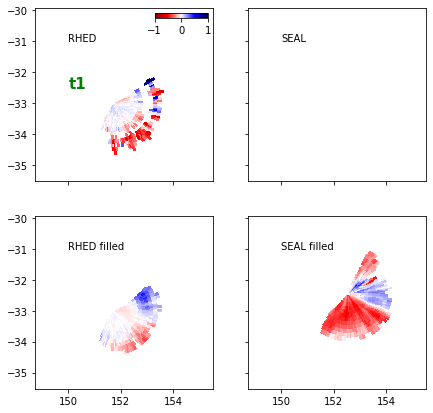

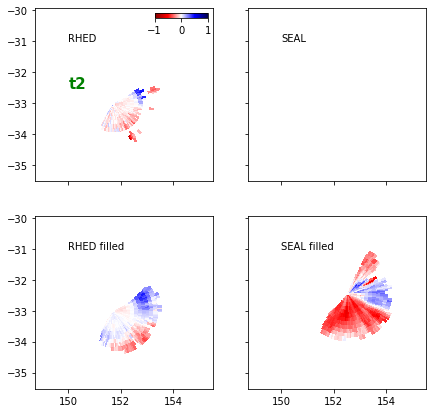

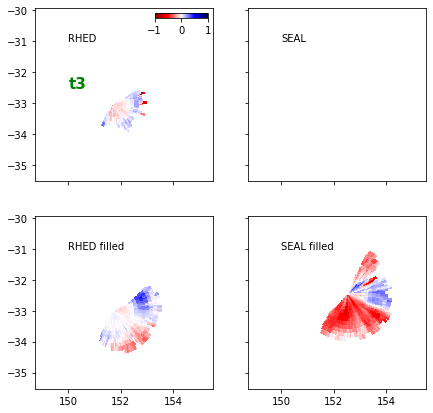

In [6]:
for i in range(-2,2):
    ts = indices_one[0][125]+i

    fig,axs=plt.subplots(ncols=2,nrows=2,sharex=True,sharey=True,figsize=(7,7))
    pc=axs[0,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,rhed_pre['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')
    axs[1,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,rhed_filled['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')

    axs[0,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,seal_pre['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')
    axs[1,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,seal_filled['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')

    axs[0,0].text(150,-31,'RHED')
    axs[1,0].text(150,-31,'RHED filled')

    axs[0,1].text(150,-31,'SEAL')
    axs[1,1].text(150,-31,'SEAL filled')
    axs[0,0].text(150,-32.5,'t'+str(i+2),fontweight='bold',color='green',fontsize=15)
    cbaxes = inset_axes(axs[0,0], width="30%", height="3%", loc=1)

    fig.colorbar(pc,cax=cbaxes,orientation='horizontal')

---

# Conclusion : DINEOF does a good job at filling and smoothing non-empty maps. Does a good job on short periods of missing maps. Bad job on both radial missing over multiple days


-> **We need to define a threshold of missing maps over which we delete the data.**


-> **We need to re-do the masks because data is bad close to the coast**


### Define bad timesteps

- Remove the beginning where SEAL is missing and there is no data before

- Remove all timesteps with both missing radials (they are bad, proof downstairs)


Text(0.5, 1.0, 'Vr SEAL Filled Both Missing')

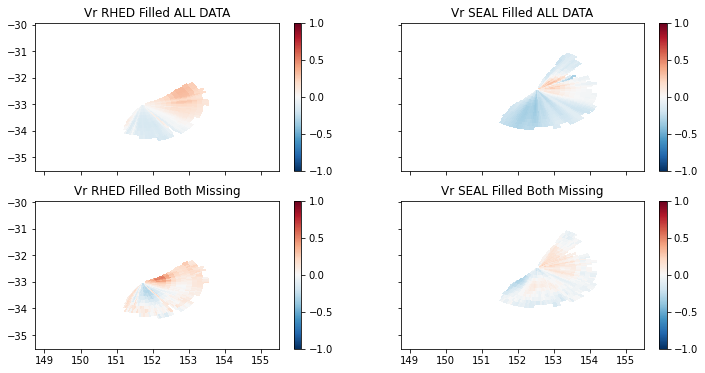

In [7]:
fig,axs=plt.subplots(ncols=2,nrows=2,figsize=(12,6),sharex=True,sharey=True)
pc0=axs[0,0].pcolor(rhed_pre['lon'].values, rhed_pre['lat'].values,
           np.nanmean(rhed_filled['v'].values,axis=0),vmin=-1,vmax=1,cmap='RdBu_r')

pc=axs[1,0].pcolor(rhed_pre['lon'].values, rhed_pre['lat'].values,
           np.nanmean(rhed_filled['v'][missing==0].values,axis=0),vmin=-1,vmax=1,cmap='RdBu_r')
fig.colorbar(pc,ax=axs[1,0])
fig.colorbar(pc0,ax=axs[0,0])
axs[0,0].set_title('Vr RHED Filled ALL DATA')
axs[1,0].set_title('Vr RHED Filled Both Missing')


pc0=axs[0,1].pcolor(seal_pre['lon'].values, seal_pre['lat'].values,
           np.nanmean(seal_filled['v'].values,axis=0),vmin=-1,vmax=1,cmap='RdBu_r')

pc=axs[1,1].pcolor(seal_pre['lon'].values, seal_pre['lat'].values,
           np.nanmean(seal_filled['v'][missing==0].values,axis=0),vmin=-1,vmax=1,cmap='RdBu_r')
fig.colorbar(pc,ax=axs[1,1])
fig.colorbar(pc0,ax=axs[0,1])
axs[0,1].set_title('Vr SEAL Filled ALL DATA')
axs[1,1].set_title('Vr SEAL Filled Both Missing')



And we have to remove long 1 radial holes that input too much variance : 
- Compute the absolute average of each map 
- Identify points where the data was missing AND that the timeseries is over median + 1 STD (if it is under median - 2 STD, we don't care, we are ok with smoothing) and boom theyre gone

Illustration plots downstairs, and some examples of removed and kept reconstructed data. Pretty happy with it.


In [8]:
missing_rhed = np.nan*np.zeros(sc_rhed_pre.shape)
missing_rhed[sc_rhed_pre==0]=1
missing_rhed[missing==0]=np.nan

missing_seal = np.nan*np.zeros(sc_seal_pre.shape)
missing_seal[sc_seal_pre==0]=1
missing_seal[missing==0]=np.nan

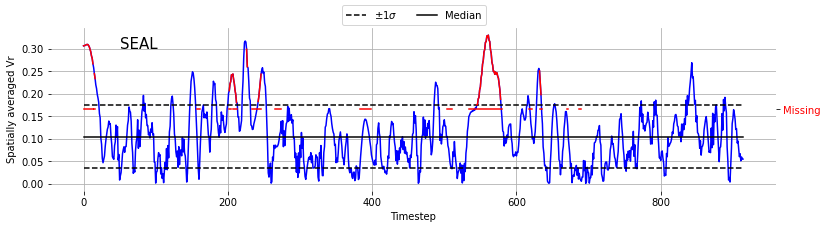

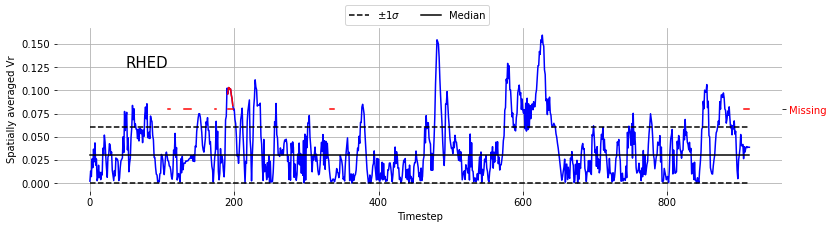

In [9]:
map_ave_abs_seal = np.abs(np.nanmean(seal_filled['v'].values,axis=(1,2)))
map_ave_abs_rhed = np.abs(np.nanmean(rhed_filled['v'].values,axis=(1,2)))

seal_median = np.nanmedian(map_ave_abs_seal)
plot_seal_max = 1*np.nanstd(map_ave_abs_seal)+seal_median
plot_seal_min = -1*np.nanstd(map_ave_abs_seal)+seal_median

rhed_median = np.nanmedian(map_ave_abs_rhed)
plot_rhed_max = 1*np.nanstd(map_ave_abs_rhed)+rhed_median
plot_rhed_min = -1*np.nanstd(map_ave_abs_rhed)+rhed_median


fig,ax=plt.subplots(figsize=(13,3))
ax.text(50,.3,'SEAL',fontsize=15)
ax.plot(map_ave_abs_seal,c='blue')
ax.plot(plot_seal_min*np.ones(missing_seal.shape),c='k',linestyle = '--',label='$\pm 1 \sigma$')
ax.plot(plot_seal_max*np.ones(missing_seal.shape),c='k',linestyle = '--')
ax.plot(seal_median*np.ones(missing_seal.shape),c='k',label='Median')
ax.set_ylabel('Spatially averaged Vr')
ax.set_xlabel('Timestep')

condi_seal = np.logical_and(missing_seal==1,map_ave_abs_seal>plot_seal_max)
to_remove_seal = np.copy(map_ave_abs_seal)
to_remove_seal[~condi_seal] = np.nan
ax.plot(to_remove_seal,c='r')


fig.legend(ncol=2,loc='upper center')

ax2=ax.twinx()
ax2.plot(missing_seal,c='r')
ax2.set_yticks([1])
ax2.set_yticklabels(['Missing'],color='red')
ax.grid()

for ax in fig.get_axes():
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)



fig,ax=plt.subplots(figsize=(13,3))
ax.text(50,.125,'RHED',fontsize=15)
ax.plot(map_ave_abs_rhed,c='blue')
ax.plot(plot_rhed_min*np.ones(missing_rhed.shape),c='k',linestyle = '--',label='$\pm 1 \sigma$')
ax.plot(plot_rhed_max*np.ones(missing_rhed.shape),c='k',linestyle = '--')
ax.plot(rhed_median*np.ones(missing_rhed.shape),c='k',label='Median')
ax.set_ylabel('Spatially averaged Vr')
ax.set_xlabel('Timestep')

condi_rhed = np.logical_and(missing_rhed==1,map_ave_abs_rhed>plot_rhed_max)
to_remove_rhed = np.copy(map_ave_abs_rhed)
to_remove_rhed[~condi_rhed] = np.nan
ax.plot(to_remove_rhed,c='r')


fig.legend(ncol=2,loc='upper center')

ax2=ax.twinx()
ax2.plot(missing_rhed,c='r')
ax2.set_yticks([1])
ax2.set_yticklabels(['Missing'],color='red')
ax.grid()

for ax in fig.get_axes():
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

In [10]:
indices_seal = np.where(condi_seal)[0]
indices_rhed = np.where(condi_rhed)[0]

indices_kept_seal = np.where(np.logical_and(missing_seal==1,~condi_seal))[0]
indices_kept_rhed = np.where(np.logical_and(missing_rhed==1,~condi_rhed))[0]

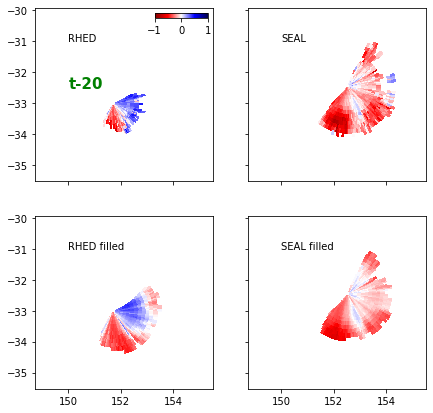

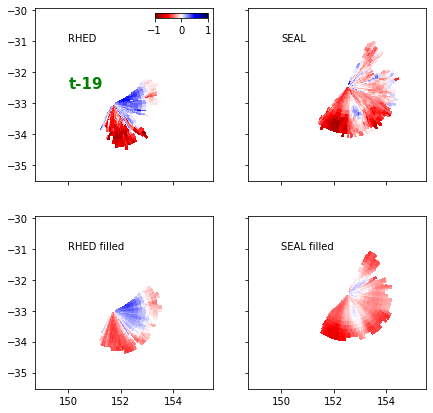

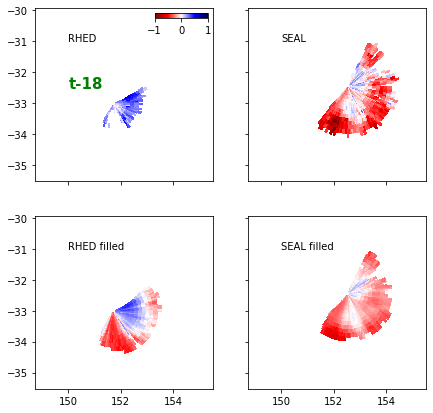

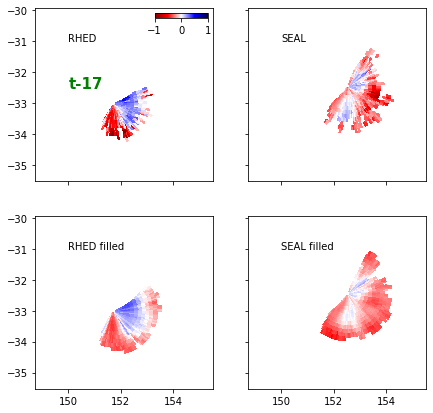

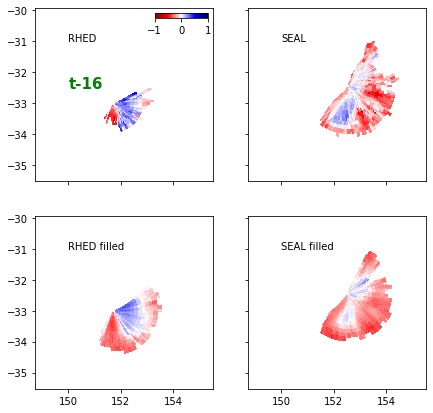

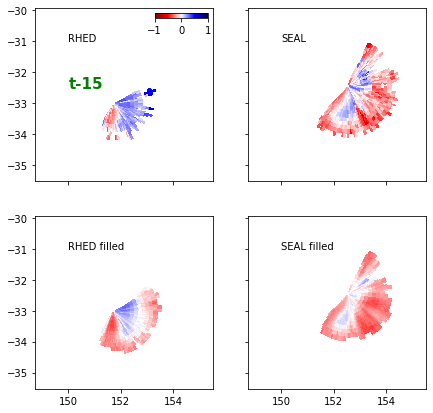

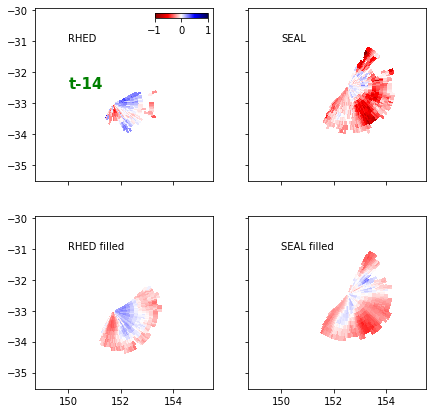

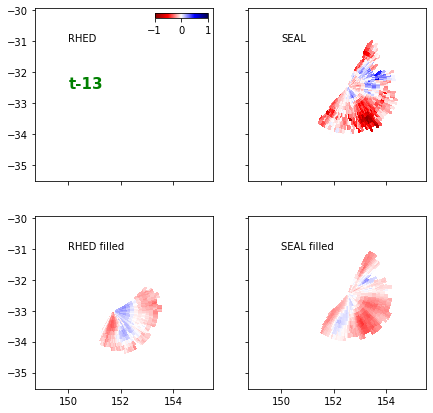

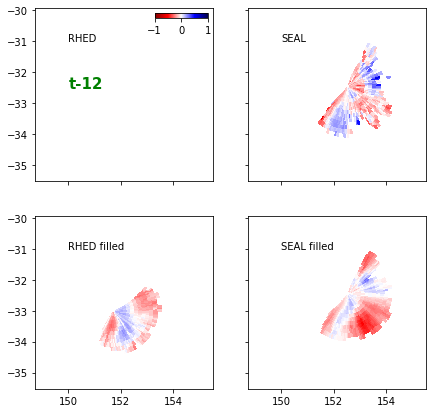

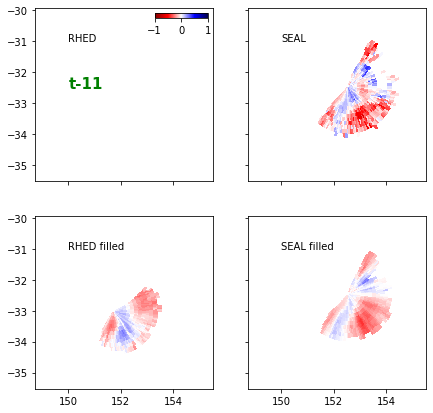

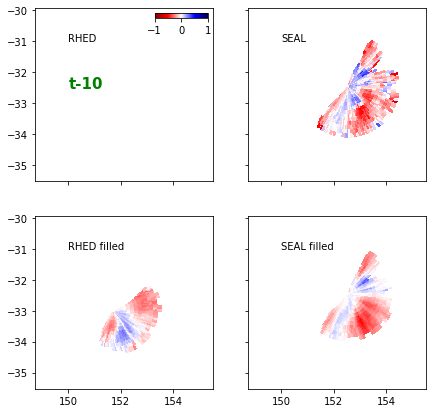

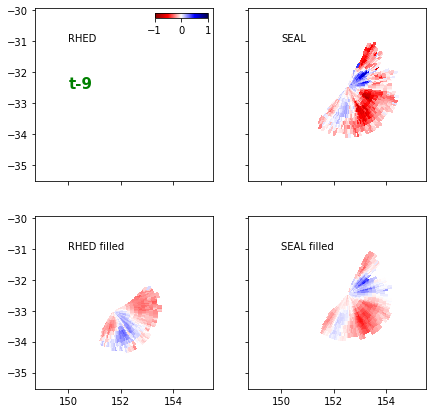

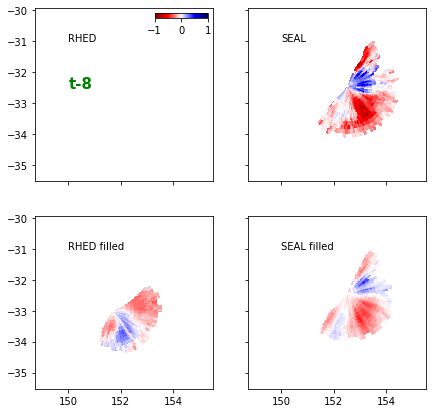

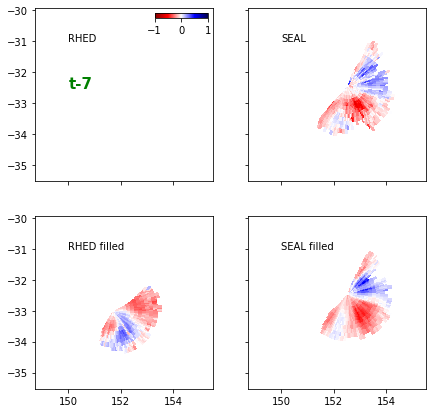

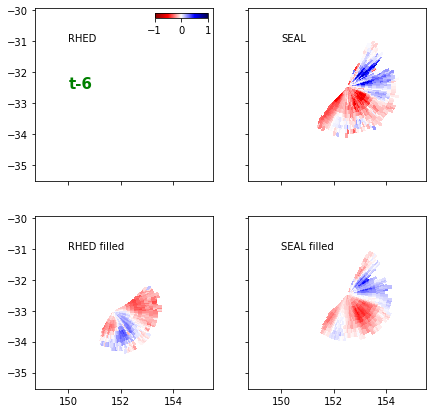

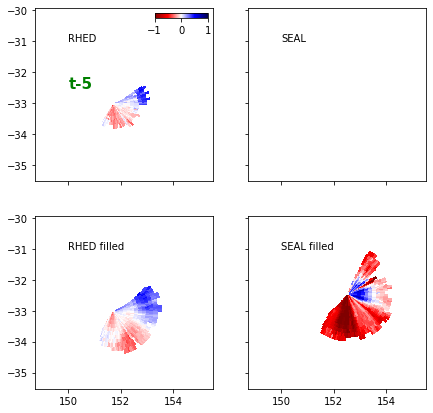

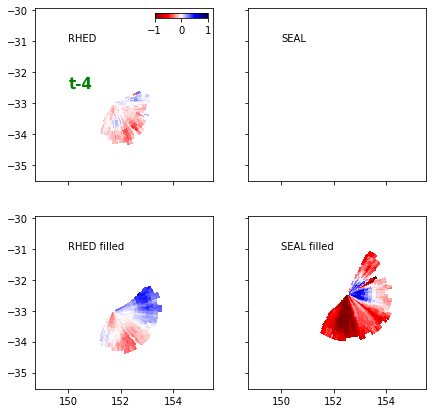

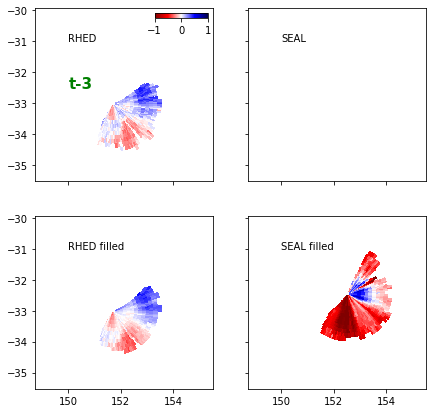

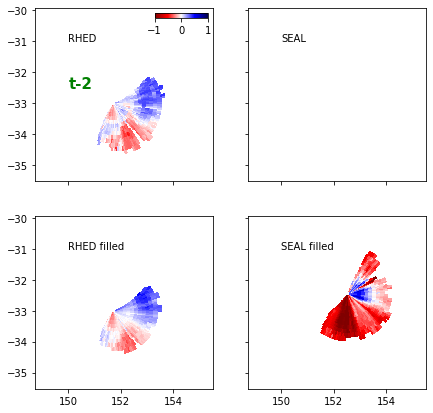

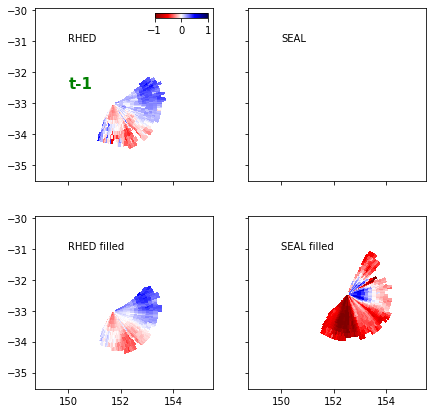

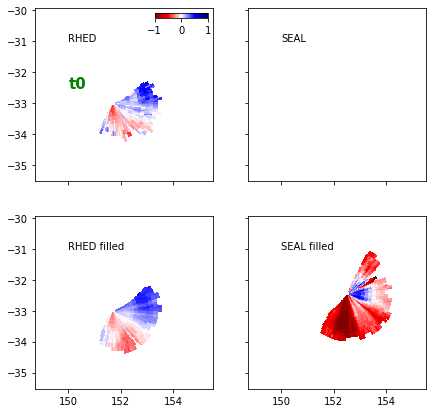

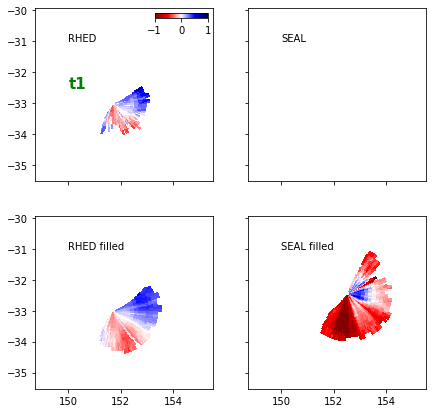

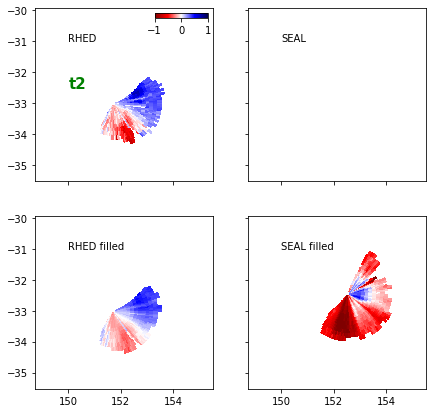

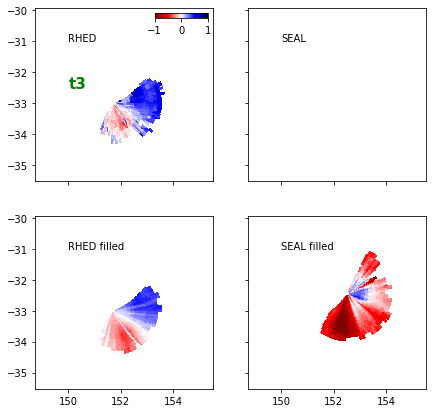

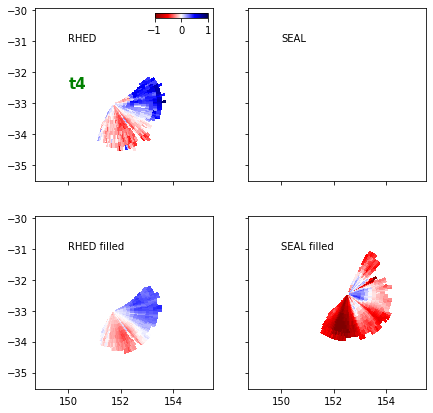

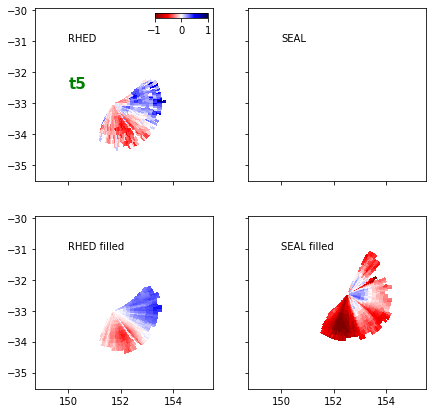

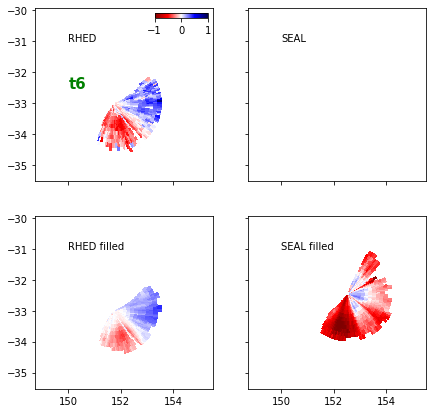

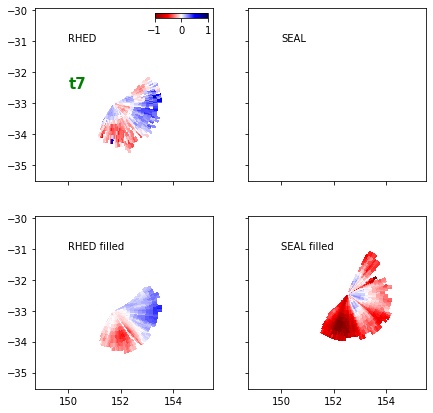

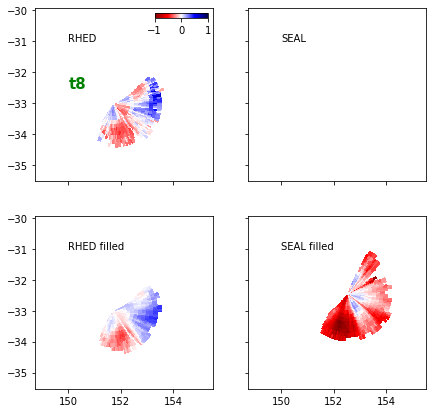

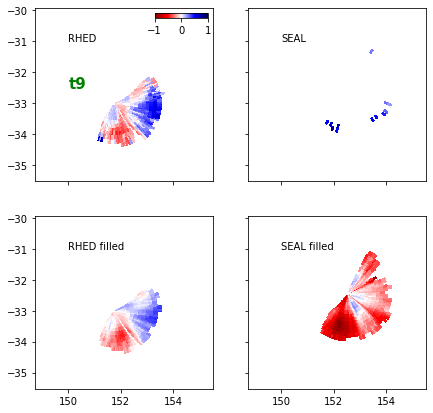

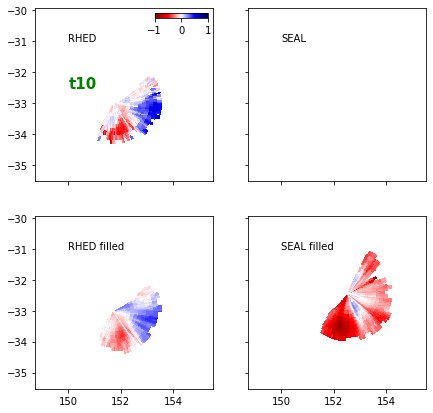

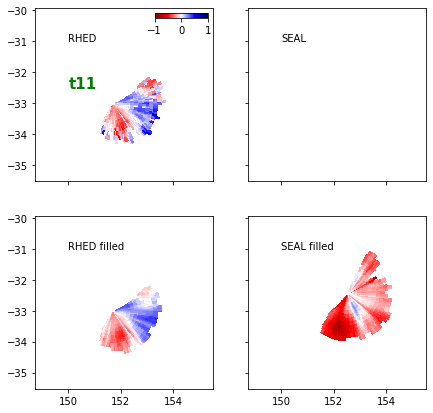

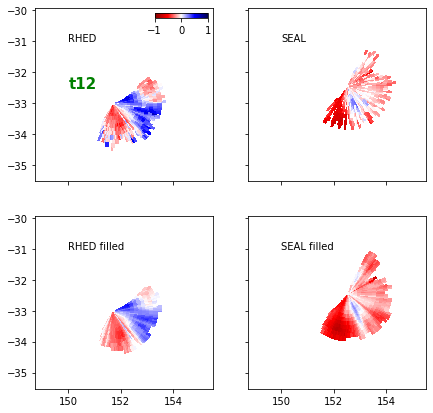

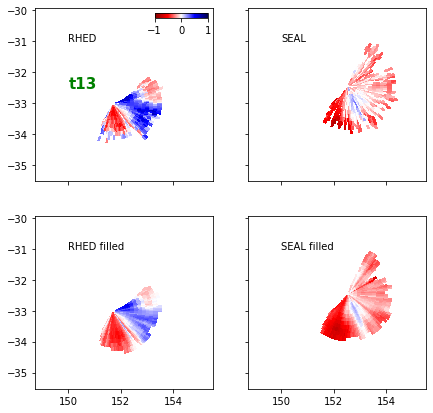

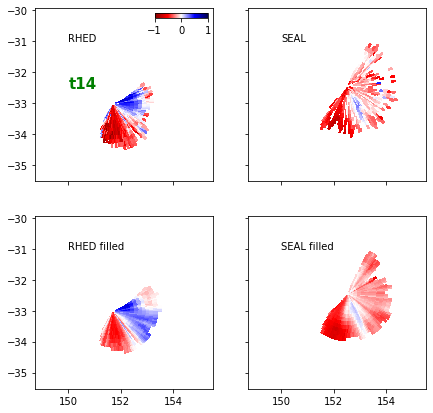

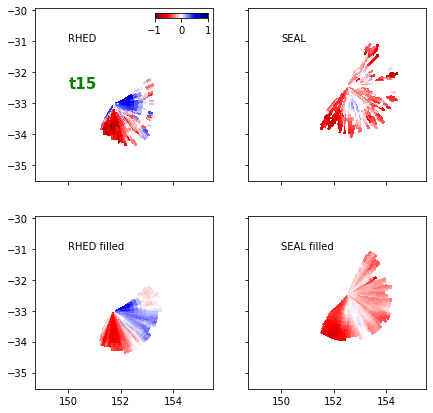

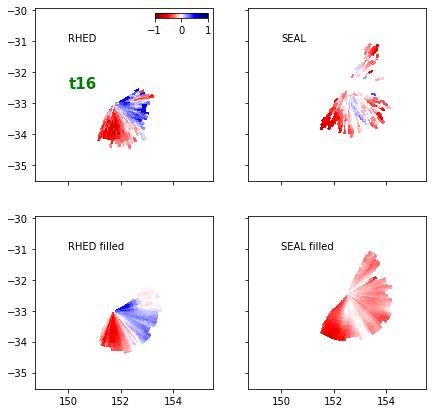

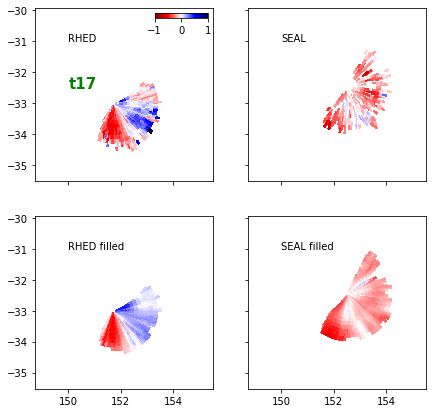

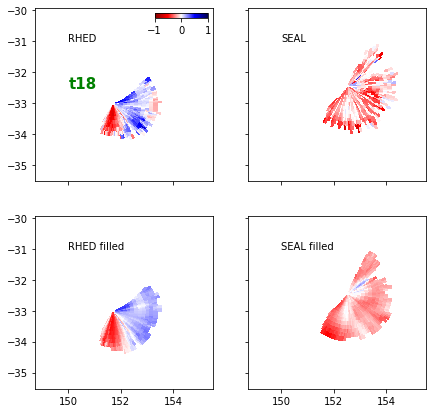

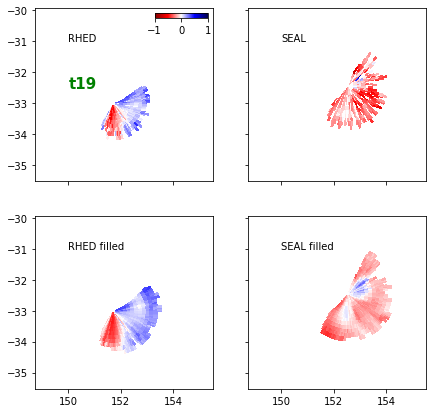

In [11]:
# example to remove
for i in range(-20,20):
    ts = indices_seal[5]+i

    fig,axs = plt.subplots(ncols = 2,
                           nrows = 2,
                           sharex = True,
                           sharey = True,
                           figsize = (7,7))
    
    pc = axs[0,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,rhed_pre['v'][ts],
                       vmin=-1,vmax=1,cmap='seismic_r')
    axs[1,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,rhed_filled['v'][ts],
                    vmin=-1,vmax=1,cmap='seismic_r')

    axs[0,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,seal_pre['v'][ts],
                    vmin=-1,vmax=1,cmap='seismic_r')
    axs[1,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,seal_filled['v'][ts],
                    vmin=-1,vmax=1,cmap='seismic_r')

    axs[0,0].text(150,-31,'RHED')
    axs[1,0].text(150,-31,'RHED filled')

    axs[0,1].text(150,-31,'SEAL')
    axs[1,1].text(150,-31,'SEAL filled')
    axs[0,0].text(150,-32.5,'t'+str(i),fontweight='bold',color='green',fontsize=15)

    cbaxes = inset_axes(axs[0,0], width="30%", height="3%", loc=1)

    fig.colorbar(pc,cax=cbaxes,orientation='horizontal')

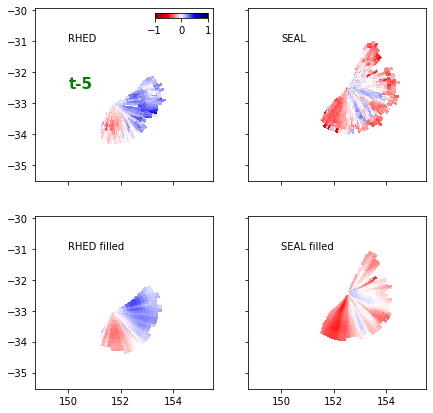

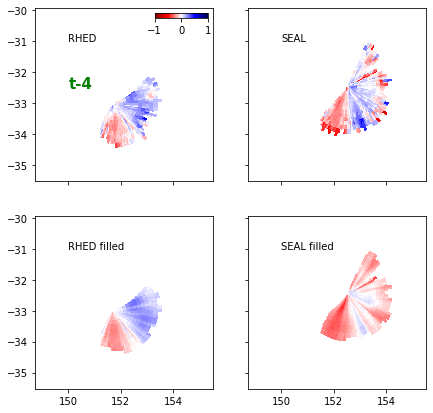

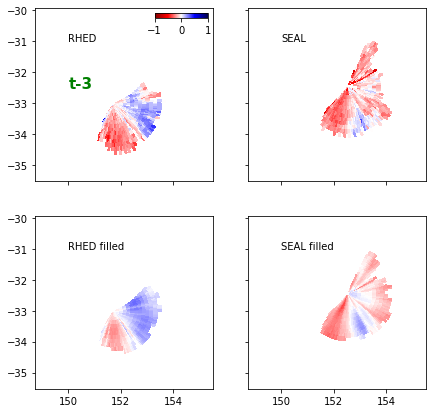

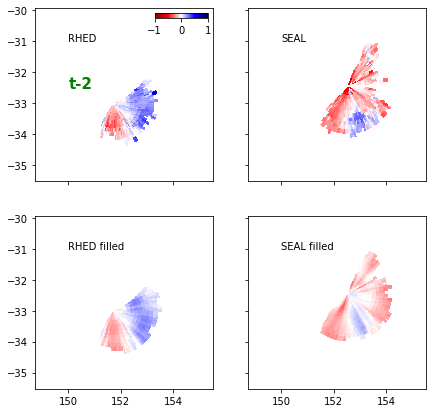

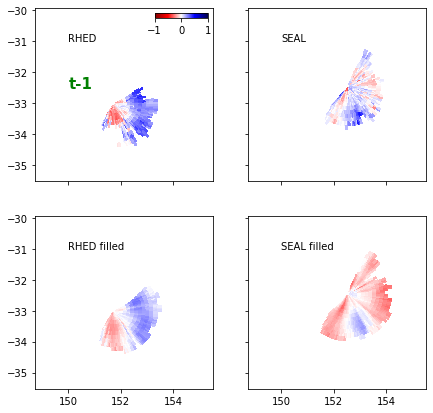

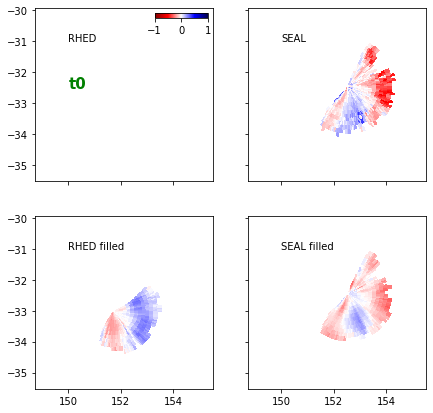

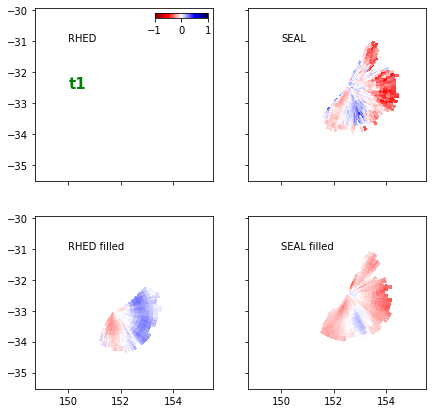

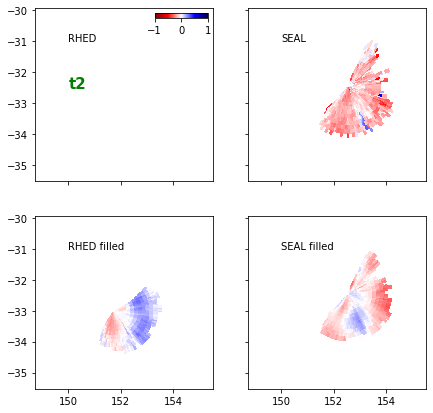

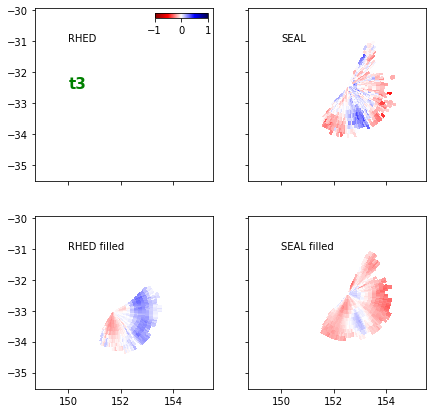

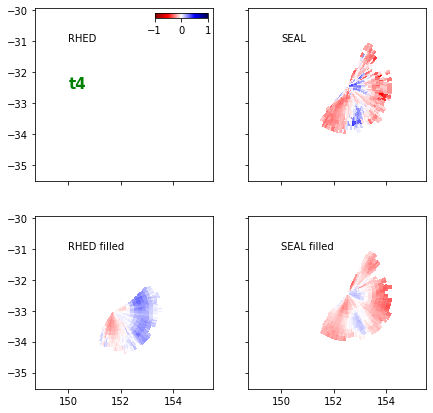

In [12]:
# example to keep
for i in range(-5,5):
    ts = indices_kept_rhed[5]+i

    fig,axs = plt.subplots(ncols = 2,
                           nrows = 2,
                           sharex = True,
                           sharey = True,
                           figsize = (7,7))
    
    pc = axs[0,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,rhed_pre['v'][ts],
                       vmin=-1,vmax=1,cmap='seismic_r')
    axs[1,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,rhed_filled['v'][ts],
                    vmin=-1,vmax=1,cmap='seismic_r')

    axs[0,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,seal_pre['v'][ts],
                    vmin=-1,vmax=1,cmap='seismic_r')
    axs[1,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,seal_filled['v'][ts],
                    vmin=-1,vmax=1,cmap='seismic_r')

    axs[0,0].text(150,-31,'RHED')
    axs[1,0].text(150,-31,'RHED filled')

    axs[0,1].text(150,-31,'SEAL')
    axs[1,1].text(150,-31,'SEAL filled')
    axs[0,0].text(150,-32.5,'t'+str(i),fontweight='bold',color='green',fontsize=15)

    cbaxes = inset_axes(axs[0,0], width="30%", height="3%", loc=1)

    fig.colorbar(pc,cax=cbaxes,orientation='horizontal')

---

### Redefine Masks

We want to remove things too close to the coast (but not too much)

Le petit croc dans la couverture temporelle (156.5E, 32S) c'est le QC qui a enlevé bcp de données là bas parce que c'était souvent pourri

(-35.0, -30.5)

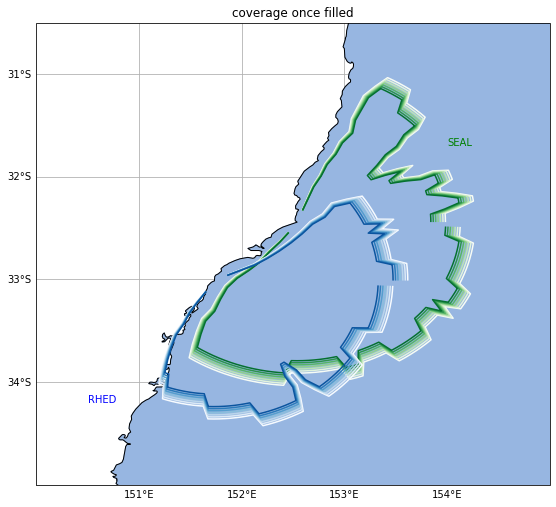

In [13]:
fig,ax=fig_cot_au(1,1)
ax.title.set_text('coverage once filled')
cf=ax.contour(seal_pre['lon'].values,seal_pre['lat'].values,get_pixel_coverage(seal_filled['v'].values),
            label='SEAL',cmap='Greens')
cf=ax.contour(rhed_pre['lon'].values,rhed_pre['lat'].values,get_pixel_coverage(rhed_filled['v'].values),
            label='RHED',cmap='Blues')
ax.text(150.5,-34.2,'RHED',color='blue')
ax.text(154,-31.7,'SEAL',color='green')
ax.set_xlim(150,155)
ax.set_ylim(-35,-30.5)

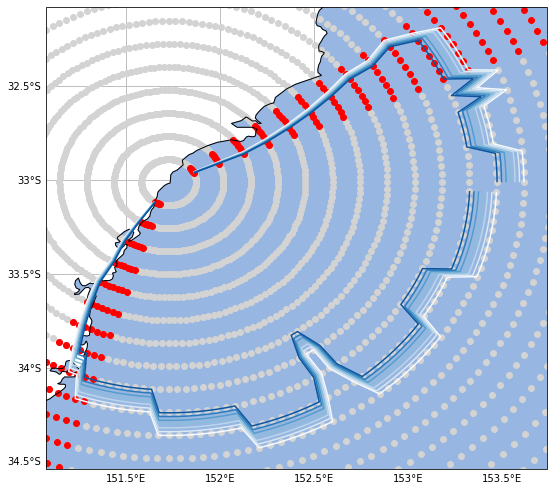

In [14]:
xmin = 120
xmax = 127

xmin2 = 12
xmax2 = 20


fig,ax=fig_cot_au(1,1)
ax.scatter(rhed_pre['lon'].values,rhed_pre['lat'].values,c='lightgrey')

ax.scatter(rhed_pre['lon'][xmin:xmax,:].values,rhed_pre['lat'][xmin:xmax,:].values,c='r')
ax.scatter(rhed_pre['lon'][xmin2:xmax2,:].values,rhed_pre['lat'][xmin2:xmax2,:].values,c='r')

ax.contour(rhed_pre['lon'].values,rhed_pre['lat'].values,get_pixel_coverage(rhed_filled['v'].values),
           cmap='Blues')

mask_rhed = np.ones((rhed_pre['lon'].values).shape)
mask_rhed[xmin:xmax,:]=np.nan
mask_rhed[xmin2:xmax2,:]=np.nan


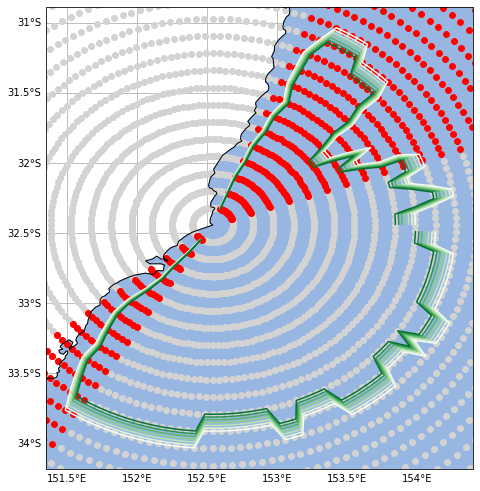

In [15]:
xmin = 110
xmax = 120

xmin2 = 10
xmax2= 35

fig,ax=fig_cot_au(1,1)
ax.scatter(seal_pre['lon'].values,seal_pre['lat'].values,c='lightgrey')
ax.scatter(seal_pre['lon'][xmin:xmax,:].values,seal_pre['lat'][xmin:xmax,:].values,c='r')

ax.scatter(seal_pre['lon'][xmin2:xmax2,:].values,seal_pre['lat'][xmin2:xmax2,:].values,c='r')

ax.contour(seal_pre['lon'].values,seal_pre['lat'].values,get_pixel_coverage(seal_filled['v'].values),
           cmap='Greens')

mask_seal = np.ones((seal_pre['lon'].values).shape)
mask_seal[xmin:xmax,:]=np.nan
mask_seal[xmin2:xmax2,:]=np.nan


(-35.0, -30.0)

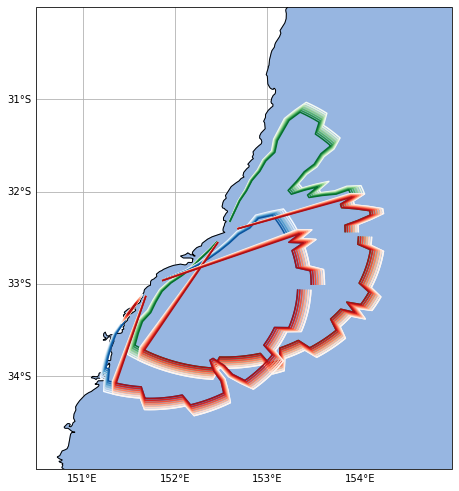

In [16]:
fig,ax=fig_cot_au(1,1)
ax.contour(seal_pre['lon'].values,seal_pre['lat'].values,get_pixel_coverage(seal_filled['v'].values),
           cmap='Greens',zorder=3)
ax.contour(seal_pre['lon'].values,seal_pre['lat'].values,get_pixel_coverage(seal_filled['v'].values*mask_seal),
           cmap='Reds',zorder=4)


ax.contour(rhed_pre['lon'].values,rhed_pre['lat'].values,get_pixel_coverage(rhed_filled['v'].values),
           cmap='Blues',zorder=3)
ax.contour(rhed_pre['lon'].values,rhed_pre['lat'].values,get_pixel_coverage(rhed_filled['v'].values*mask_rhed),
           cmap='Reds',zorder=5)

ax.set_xlim(150.5,155)
ax.set_ylim(-35,-30)

---
## Save Temporal and Spatial Masking to .npy files for post processing

In [25]:
path_save = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data_Processing/Gap_Filling/run_newcastle/pre_post_processing/'
#np.save(path_save+'PostProcessNewcastleMasks.npy',[mask_rhed, mask_seal, mask_time_rhed, mask_time_seal])
mask_time_rhed = np.ones(condi_rhed.shape)
mask_time_rhed[condi_rhed]=np.nan

mask_time_seal = np.ones(condi_seal.shape)
mask_time_seal[condi_seal]=np.nan


mask_time_all = np.ones(condi_seal.shape)
mask_time_all[missing==0]=np.nan

np.save(path_save+'PostProcessNewcastleMasks_maskrhed.npy',mask_rhed)
np.save(path_save+'PostProcessNewcastleMasks_maskseal.npy',mask_seal)
np.save(path_save+'PostProcessNewcastleMasks_maskrhed_time.npy',mask_time_rhed)
np.save(path_save+'PostProcessNewcastleMasks_maskseal_time.npy',mask_time_seal)
np.save(path_save+'PostProcessNewcastleMasks_maskall_time.npy',mask_time_all)

#[mask_rhed, mask_seal, mask_time_rhed, mask_time_seal]=np.load(path_save+'PostProcessNewcastleMasks.npy',allow_pickle=True)

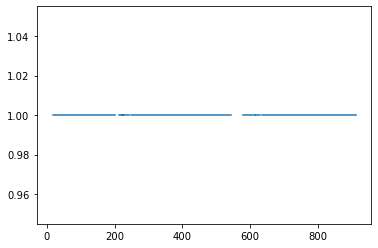

In [28]:
plt.plot(mask_time_seal)